In [1]:
import torch
print(torch.cuda.is_available())  # Should print True

True


In [2]:
from google.colab import files
files.upload()   # Upload kaggle.json

Saving kaggle (2).json to kaggle (2) (1).json


{'kaggle (2) (1).json': b'{"username":"sanjaydkd","key":"3bc2aa31a3b1b2efbffc66be8c62b14d"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!unzip chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/IM-0435-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0435-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0437-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0438-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001-0002.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0439-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0440-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0441-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0442-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0444-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0445-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0446-0001.jpeg  
  inflating: chest_xray/train/NORMAL/IM-0447-0001.jpeg  
  inflating:

In [18]:
import os
os.rename('chest_xray', 'data')

OSError: [Errno 39] Directory not empty: 'chest_xray' -> 'data'

In [8]:
!pip install torch torchvision matplotlib scikit-learn

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [10]:
# -----------------------------
# 1. Data Augmentation (IMPROVED)
# -----------------------------
transform = {
    'train': transforms.Compose([
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
    ]),
    'val': transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
    ])
}


In [12]:
# -----------------------------
# 2. Load Dataset
# -----------------------------
train_data = datasets.ImageFolder('data/train', transform=transform['train'])
from torch.utils.data import ConcatDataset

val_data1 = datasets.ImageFolder('data/val', transform=transform['val'])
val_data2 = datasets.ImageFolder('data/test', transform=transform['val'])

val_data = ConcatDataset([val_data1, val_data2])

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
# val_loader = torch.utils.data.DataLoader(val_data, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32, shuffle=True)

In [13]:
# -----------------------------
# 3. Pretrained Model
# -----------------------------
model = models.resnet18(pretrained=True)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last block (Fine-tuning)
for param in model.layer4.parameters():
    param.requires_grad = True

# Modify classifier
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, len(train_data.classes))
)

model = model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
# -----------------------------
# 4. Loss & Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [15]:
# -----------------------------
# 5. Training
# -----------------------------
num_epochs = 10
best_val_loss = float('inf')
patience = 2
counter = 0

train_losses, val_losses = [], []
train_acc, val_acc = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / len(train_data)

    train_losses.append(train_loss)
    train_acc.append(train_accuracy)

    # Validation
    model.eval()
    val_loss, val_correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_accuracy = val_correct / len(val_data)

    val_losses.append(val_loss)
    val_acc.append(val_accuracy)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")



Epoch 1/10
Train Loss: 0.4260, Train Acc: 0.8397
Val Loss: 0.3615, Val Acc: 0.8484

Epoch 2/10
Train Loss: 0.1938, Train Acc: 0.9411
Val Loss: 0.3452, Val Acc: 0.8438

Epoch 3/10
Train Loss: 0.1339, Train Acc: 0.9532
Val Loss: 0.4075, Val Acc: 0.8328

Epoch 4/10
Train Loss: 0.1020, Train Acc: 0.9666
Val Loss: 0.3565, Val Acc: 0.8547

Epoch 5/10
Train Loss: 0.0970, Train Acc: 0.9659
Val Loss: 0.4408, Val Acc: 0.8453

Epoch 6/10
Train Loss: 0.0831, Train Acc: 0.9732
Val Loss: 0.4466, Val Acc: 0.8453

Epoch 7/10
Train Loss: 0.0810, Train Acc: 0.9753
Val Loss: 0.4191, Val Acc: 0.8500

Epoch 8/10
Train Loss: 0.0743, Train Acc: 0.9743
Val Loss: 0.4740, Val Acc: 0.8422

Epoch 9/10
Train Loss: 0.0654, Train Acc: 0.9787
Val Loss: 0.4634, Val Acc: 0.8484

Epoch 10/10
Train Loss: 0.0604, Train Acc: 0.9787
Val Loss: 0.4086, Val Acc: 0.8656


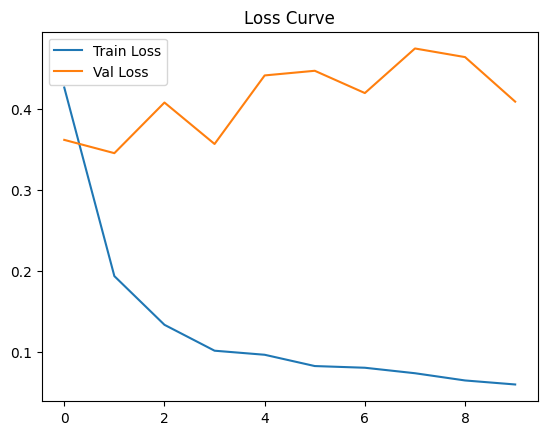

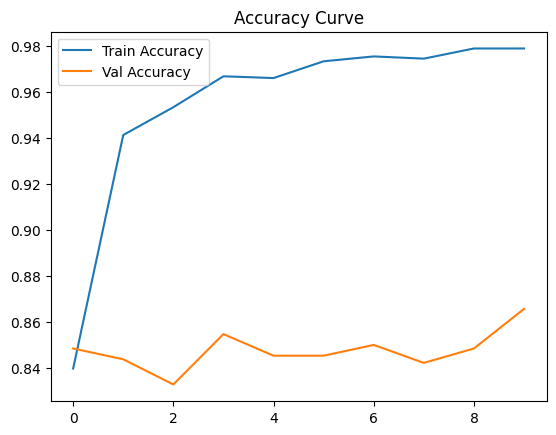

In [16]:
# -----------------------------
# 6. Graphs
# -----------------------------
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [17]:
# -----------------------------
# 7. Evaluation
# -----------------------------
print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Confusion Matrix:
[[158  84]
 [  2 396]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.65      0.79       242
           1       0.82      0.99      0.90       398

    accuracy                           0.87       640
   macro avg       0.91      0.82      0.84       640
weighted avg       0.89      0.87      0.86       640

